In [1]:
RUNNING_ON_NRP = True

In [2]:
# jupyter notebook nautilus installs 

# %cd ..
# !ls
# # %pip install -e .

# This is a much faster way to install dependencies when using jupyterhub on NRP - not for use in production
# You may need to restart the kernel after running this block. 
if (RUNNING_ON_NRP):
    %pip install -e ../. --no-deps
    
    %pip install xgcm 
    %pip install zarr
    %pip install boto3
    %pip install ujson
    %pip install scikit-fmm

Obtaining file:///C:/Users/Jake%20Tallman/PycharmProjects/dbof-in-native-grid
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for dbof-in-native-grid (pyproject.toml): started
  Building editable for dbof-in-native-grid (pyproject.toml): finished with status 'done'
  Created wheel for dbof-in-native-grid: filename=dbof_in_native_grid-0.0.dev0-0.editable-py3-none-any.whl size=2241 sha256=942a2d8b5b41395cea0feefb257b380730359550e0658101fe216ebd6611c6e5
  Stored in directory: C:\Users\Jake Tallman\AppData\Local\Temp\pip-ephem-whe


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm
import dataset_creation.zarr_dataset as zarr_dataset

In [ ]:
# for rnp jupyter 
# !sudo curl "https://awscli.amazonaws.com/awscli-exe-linux-x86_64.zip" -o "awscliv2.zip"
# !sudo unzip awscliv2.zip
# !sudo ./aws/install

In [6]:
# Note: include trailing "/" please
bucket = "llc/"
folder = "native_grid_dbof_training_data/"
s3_endpoint = "https://s3-west.nrp-nautilus.io"

In [7]:
import fsspec
import pandas as pd

fs_synch = fsspec.filesystem(
    "s3", #
    asynchronous=False,
    client_kwargs={
        "endpoint_url": s3_endpoint,

    },

    # These become botocore.client.Config(...)
    config_kwargs={
        "signature_version": "s3v4",
        "request_checksum_calculation": "when_required",
        "s3": {
            "addressing_style": "path",
            "payload_signing_enabled": False,
            "use_accelerate_endpoint": False,
            "use_dualstack_endpoint": False,
        },
    },
)

fs = fsspec.filesystem(
        "s3",  #
        asynchronous=True,
        client_kwargs={
            "endpoint_url": s3_endpoint,

        },

        # These become botocore.client.Config(...)
        config_kwargs={
            "signature_version": "s3v4",
            "request_checksum_calculation": "when_required",
            "s3": {
                "addressing_style": "path",
                "payload_signing_enabled": False,
                "use_accelerate_endpoint": False,
                "use_dualstack_endpoint": False,
            },
        },
    )

# Comparing Biases Accross a Year of Samples

In [8]:
run_id = "test00/"

In [9]:
files = fs_synch.glob(
    f"llc/native_grid_dbof_training_data/{run_id}metadata/*.parquet"
)

meta_df = pd.read_parquet(files, filesystem=fs_synch)

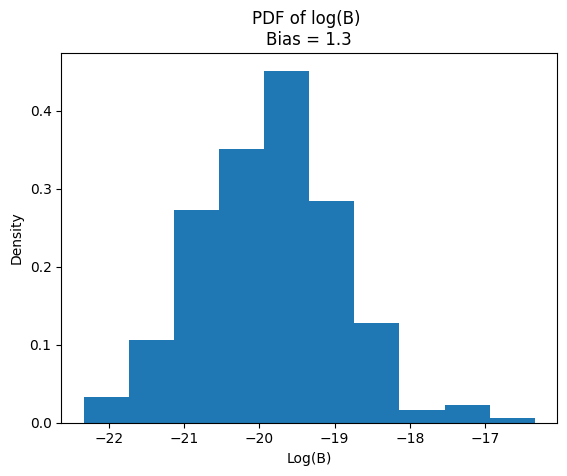

In [11]:
hist, edges = np.histogram(meta_df["log_grad_b_2_center"], bins=10, density=True)

plt.bar(
    edges[:-1],
    hist,
    width=np.diff(edges),
    align="edge"
)

plt.xlabel("Log(B)")
plt.ylabel("Density")
plt.title("PDF of log(B) \nBias = 1.3")

plt.show()

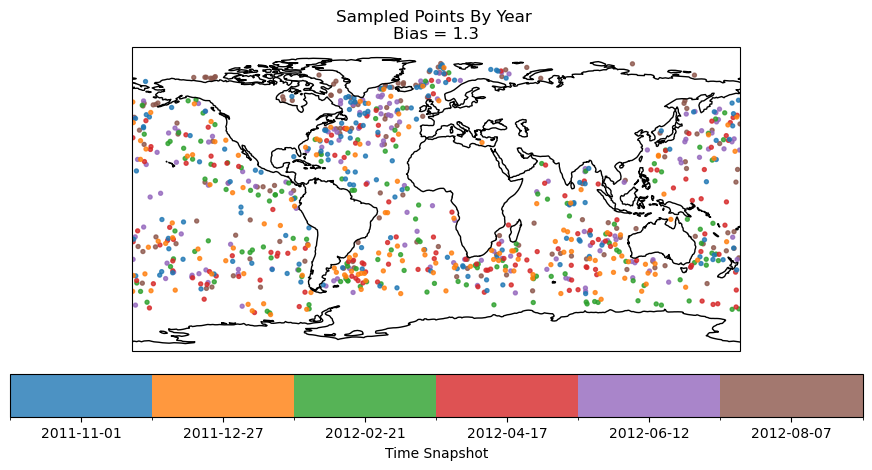

In [32]:
lats = meta_df["center_lat"].values
lons = meta_df["center_lon"].values

timestamps = pd.to_datetime(meta_df["time_snapshot"])

timestamps = pd.Series(u.strftime("%Y-%m-%d") for u in timestamps)

unique_times = timestamps.sort_values().unique()

time_to_index = {t: i for i, t in enumerate(unique_times)}

time_indices = np.array([time_to_index[t] for t in timestamps])
n_times = len(unique_times)
# discrete colormap
cmap = plt.get_cmap("tab10")#, n_times)
norm = BoundaryNorm(np.arange(-0.5, n_times + 0.5, 1), n_times)

# ---- plot ----
fig = plt.figure(figsize=(11, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()
ax.coastlines()

sc = ax.scatter(
    lons,
    lats,
    c=time_indices,
    cmap=cmap,
    norm=norm,
    s=8,
    alpha=0.8,
    transform=ccrs.PlateCarree()
)

# discrete colorbar with timestamp labels
cbar = plt.colorbar(
    sc,
    ax=ax,
    orientation="horizontal",
    pad=0.06,
    ticks=np.arange(n_times)
)

cbar.set_ticklabels([str(t) for t in unique_times])
cbar.set_label("Time Snapshot")

plt.title("Sampled Points By Year \nBias = 1.3")
plt.show()


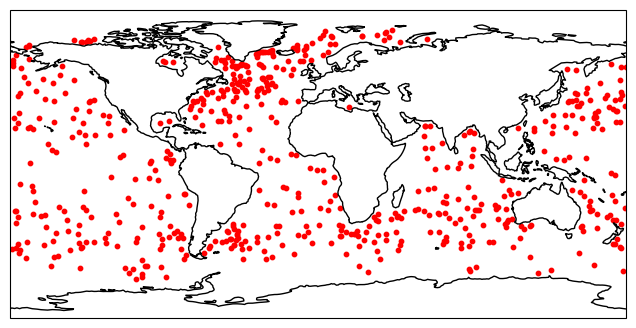

In [101]:
# import matplotlib.pyplot as plt
import cartopy.crs as ccrs

print()

lats = meta_df["center_lat"]
lons = meta_df["center_lon"]


fig = plt.figure(figsize=(8, 4))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()
ax.set_global()
ax.scatter(
    lons,
    lats,
    s=10,
    color="red",
    transform=ccrs.PlateCarree()
)

plt.show()

In [102]:
lats = meta_df["center_lat"].values
lons = meta_df["center_lon"].values
years = meta_df["time_snapshot"].values

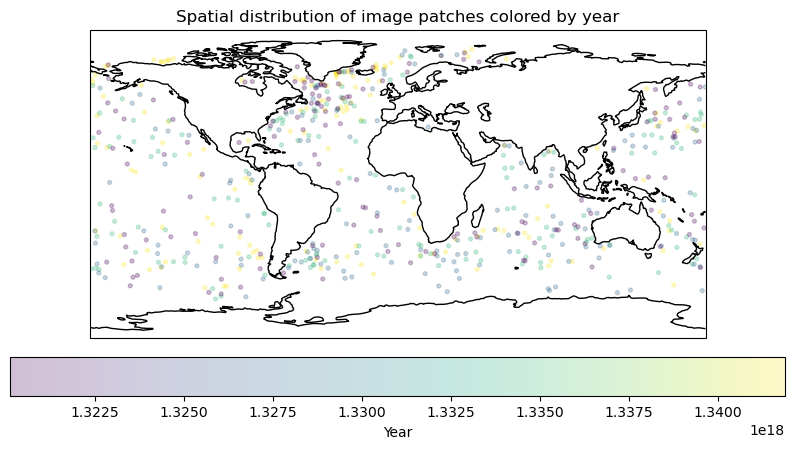

In [103]:
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()
ax.coastlines()

sc = ax.scatter(
    lons,
    lats,
    c=years,
    cmap="viridis",     # or "plasma", "turbo", "cividis"
    s=8,
    alpha=0.25,         # <<< transparency = density visualization
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.05)
cbar.set_label("Year")

plt.title("Spatial distribution of image patches colored by year")
plt.show()

In [18]:
reader = zarr_dataset.ZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name="cutout_dataset_creation.zarr",
    fs=fs
)

img, img_id = reader.get_image(10)

imgs, ids = reader.get_images([449,10,200,250,4,5,6,7,8,9,10])

In [17]:
reader.num_images

450

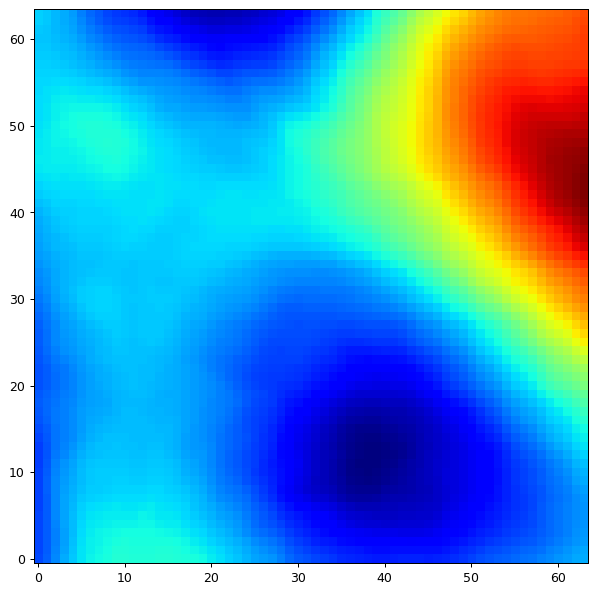

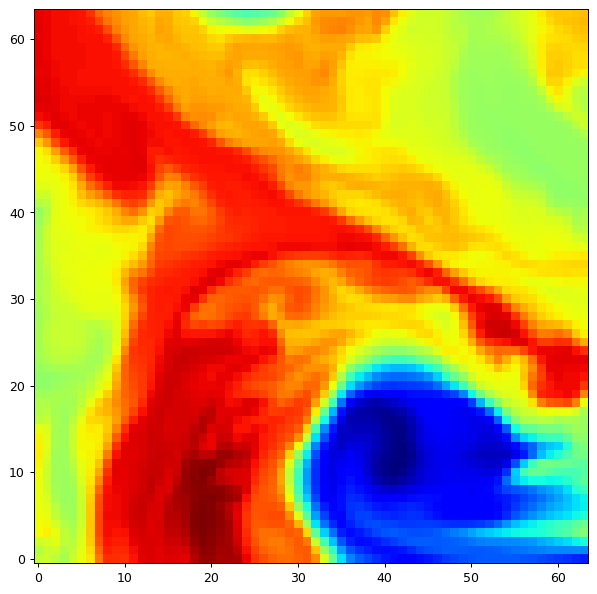

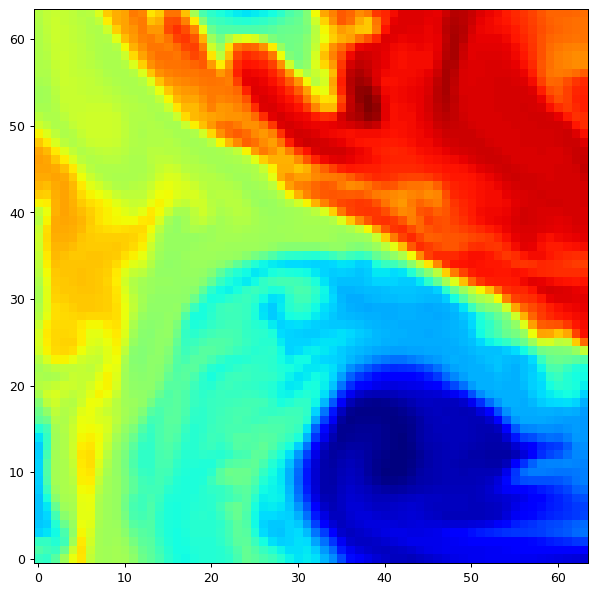

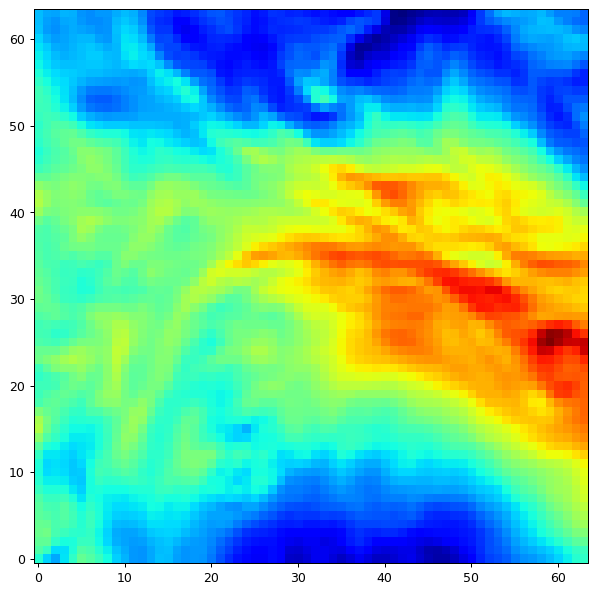

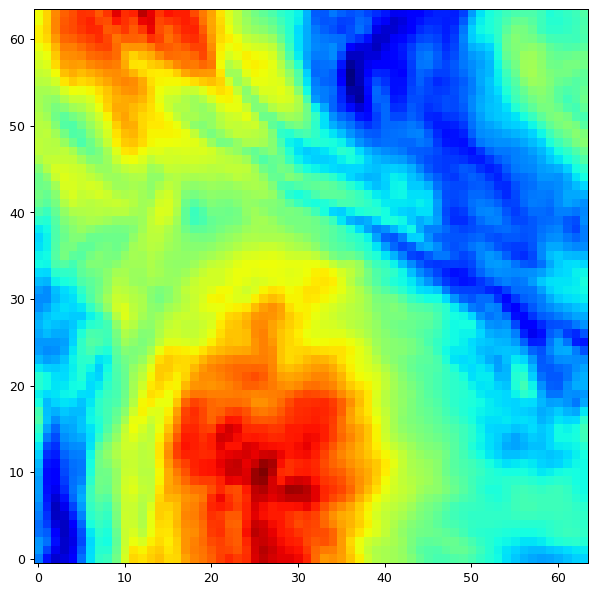

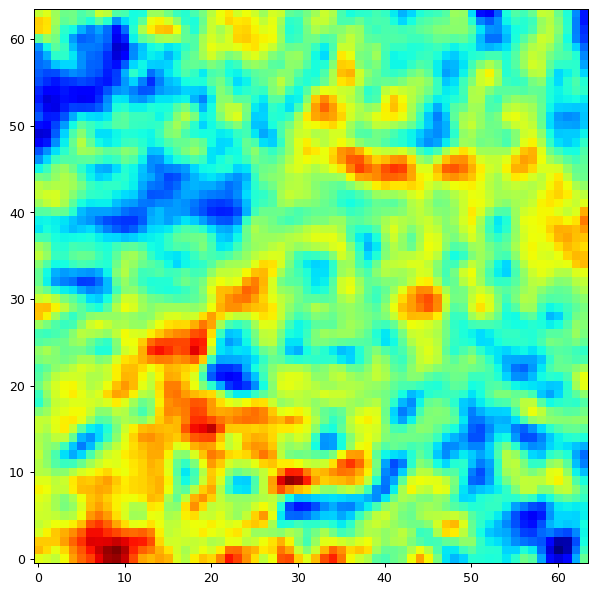

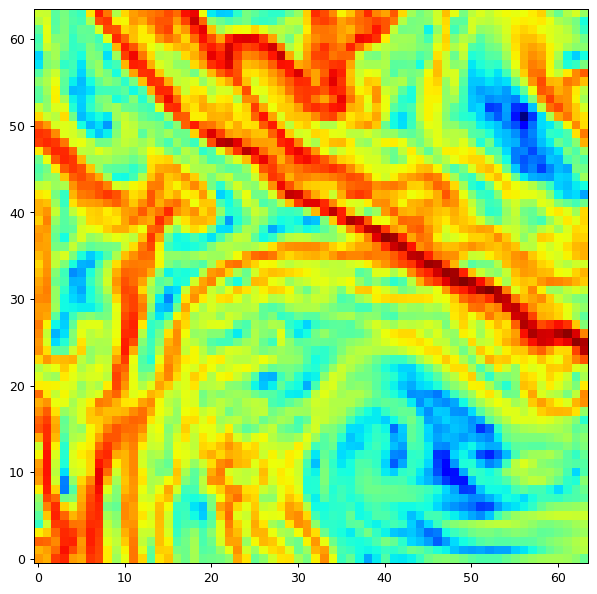

In [20]:
img, img_id = reader.get_image(449)
for i in range(len(img)):
        
    plt.figure(figsize=(8,8), dpi= 90)
    plt.imshow(img[i],origin='lower',cmap='jet')

In [107]:
%pip install cmocean
import cmocean


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [25]:
# todo add ids and lat lon
import cmocean
feature_channels = ["Eta", "Salt", "Theta", "U", "V", "W", "log_gradb"]

def plot_image_features(imgs, ids):
    """
    imgs: (N, C, H, W)
    """

    N, C, H, W = imgs.shape

    fig = plt.figure(figsize=(2.5*(C+1), 2.5*N))
    gs = fig.add_gridspec(N, C + 1, wspace=0.5, hspace=0.15)

    for i in range(N):
        row_data = imgs[i]

        for c in range(C):
            ax = fig.add_subplot(gs[i, c])

            # vmin = np.nanmin(row_data[c])
            # vmax = np.nanmax(row_data[c])

            
            if c == 0:
                cmap = cmocean.cm.gray
            elif c == 1 :
                cmap = cmocean.cm.haline
            elif c == 2 :
                cmap = cmocean.cm.thermal
            elif c == 6 :
                cmap = cmocean.cm.diff
            else :
                cmap = cmocean.cm.speed
                

        
            im = ax.imshow(row_data[c], cmap=cmap) #, vmin=vmin, vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])

            if i == 0:
                ax.set_title(f"{feature_channels[c]}", fontsize=10)

            fig.colorbar(
                im,
                ax=ax,
                fraction=0.046,
                pad=0.01 #format="%4.2"
            )

        # # colorbar (per image)
        # cax = fig.add_axes([
        #     0.92,
        #     1 - (i + 1)/N + 0.01,
        #     0.015,
        #     0.8/N
        # ])
        # plt.colorbar(im, cax=cax)

        # # lat/lon panel
        row = meta_df[meta_df["dataset_index"] == ids[0]]


        ax_loc = fig.add_subplot(gs[i, -1])
        ax_loc.axis("off")
        ax_loc.text(
            0.5, 0.6,
            f"lat: {row.center_lat}\nlon: {row.center_lon}",
            ha="center",
            va="center",
            fontsize=10
        )

    plt.show()

In [22]:
rand_indices = np.random.randint(0, reader.num_images, size=20)
imgs, ids = reader.get_images(rand_indices)

In [23]:

row = meta_df[meta_df["dataset_index"] == ids[0]]
row.center_lat
row.center_lon

Series([], Name: center_lon, dtype: float64)

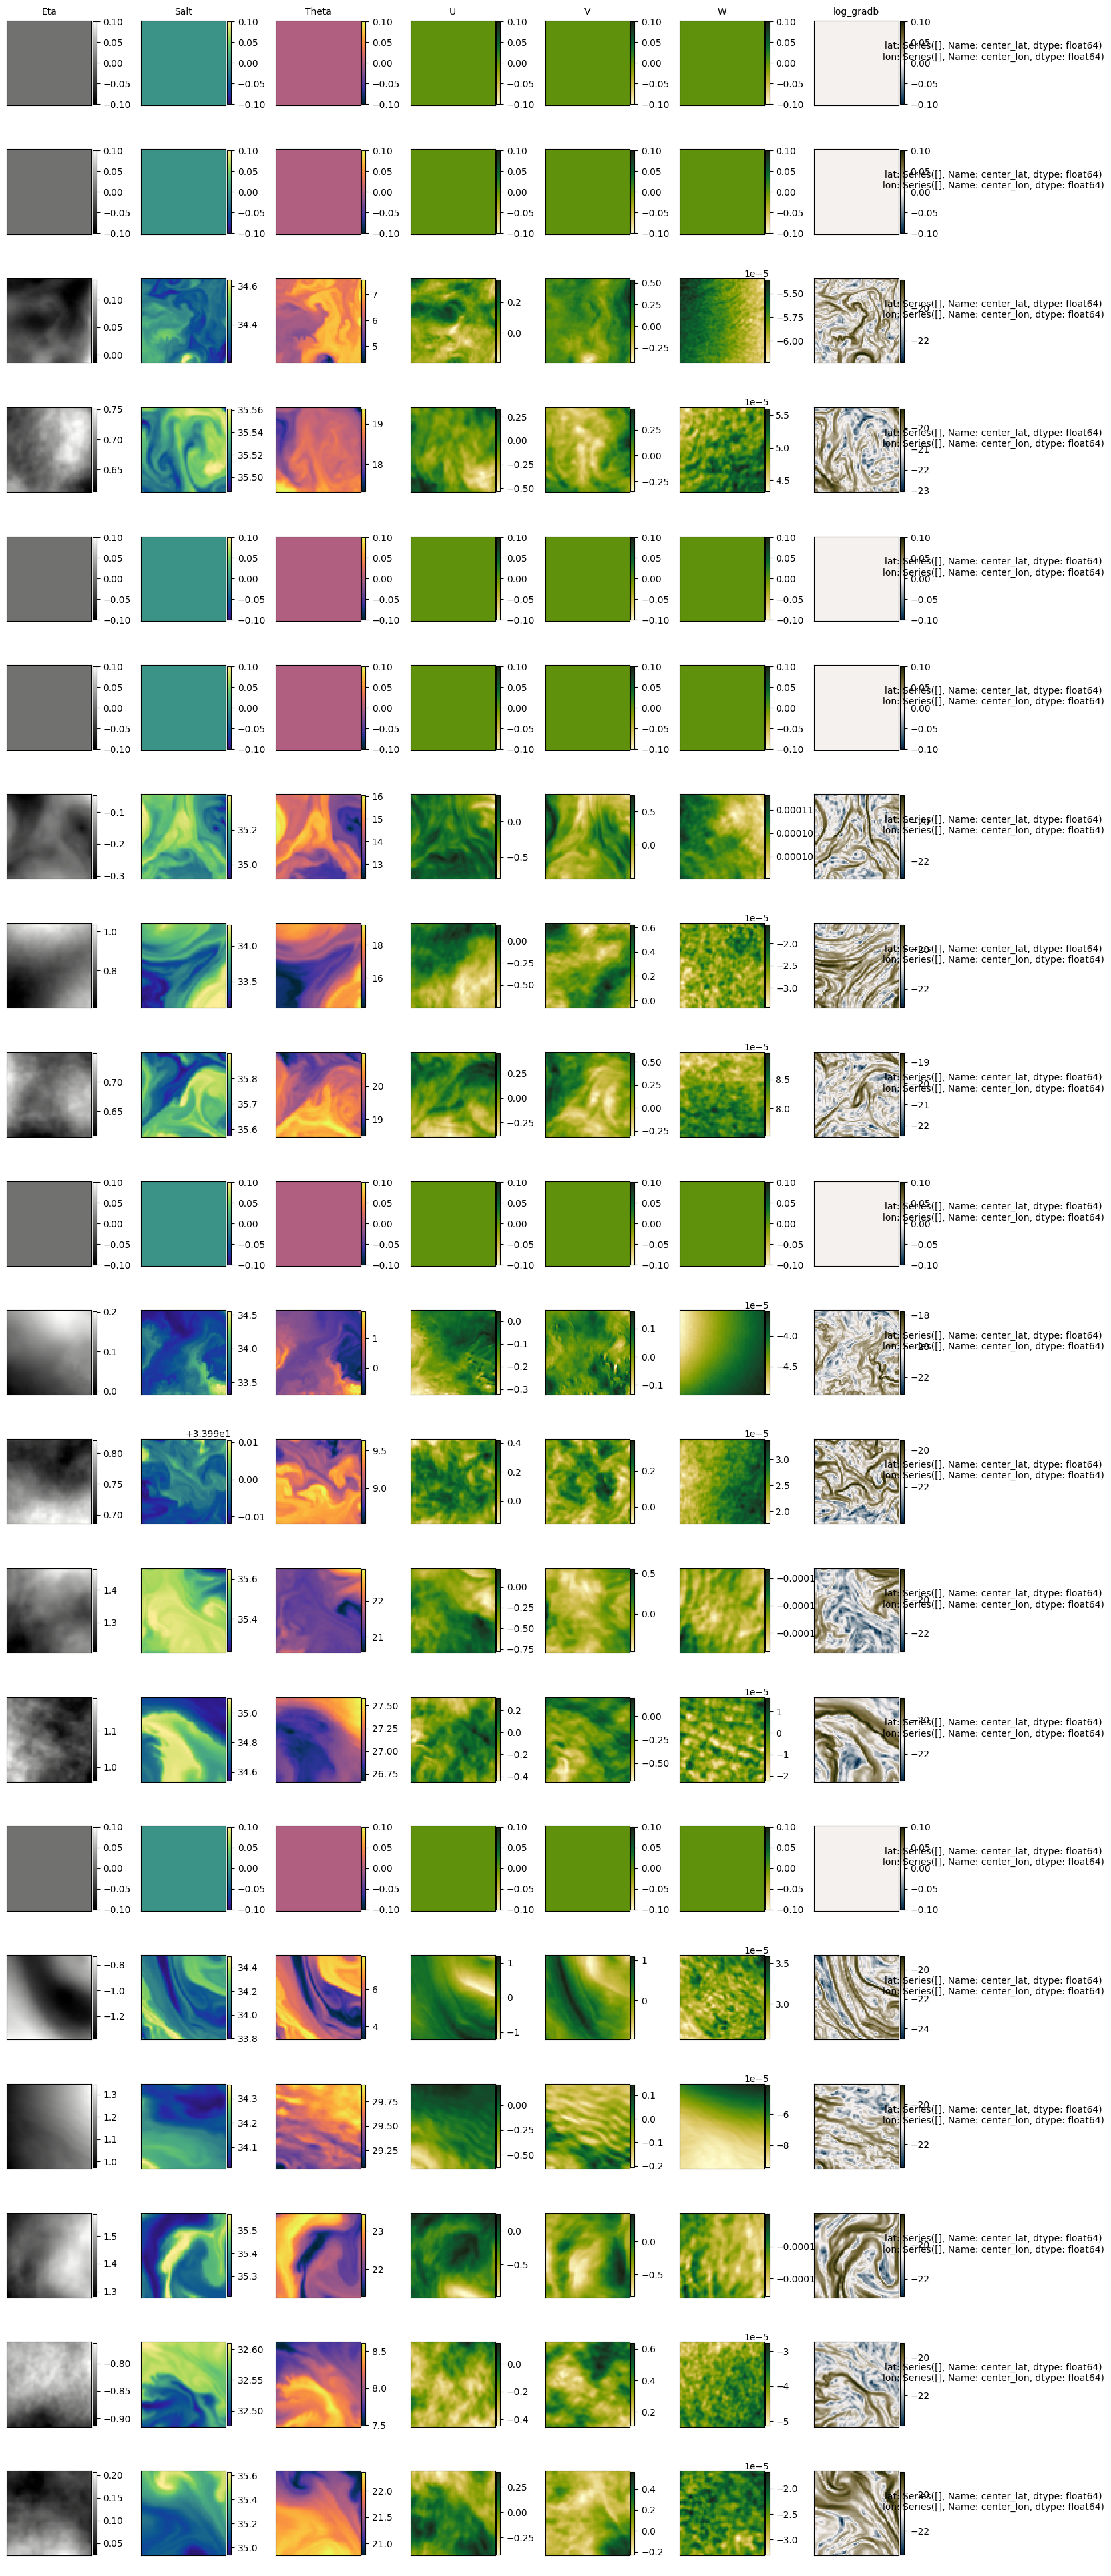

In [26]:
plot_image_features(imgs, ids)

In [ ]:
# !aws --endpoint https://s3-west.nrp-nautilus.io s3 ls s3://llc/native_grid_dbof_training_data/script_test_00/ --human-readable